In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

sys.path.append(str(project_root))

print(project_root)

C:\Users\SAMVIT\PycharmProjects\PythonProject2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from database_connection import load_core_tables
from risk_analytics import build_counterparty_exposure, calculate_portfolio_kpis, concentration_by_dimension,calculate_saccr_exposure
from stress_testing import run_stress_testing

In [3]:
counterparties_df, trades_df, collateral_df, margin_calls_df, market_data_df, stress_scenarios_df = load_core_tables()

counterparties_df.head()

,counterparty_id,counterparty_name,credit_rating,sector,country,legal_entity_type,onboarding_date,risk_limit,is_clearing_member
0,1,HDFC Bank Treasury,BBB,Broker Dealer,India,Broker Dealer,2016-12-11,2.099380e+09,True
1,2,ICICI Securities,A,Corporate Treasury,India,Corporate,2021-06-20,7.996953e+08,False
2,3,Axis Bank Global Markets,BB,Insurance,India,NBFC,2023-12-16,6.061740e+09,False
3,4,State Bank of India Markets,BBB,Asset Manager,India,Broker Dealer,2017-11-29,5.237743e+09,True
4,5,Kotak Mahindra Capital,AA,Bank,India,Fund,2019-09-27,5.509866e+09,True


In [4]:
trades_df.head()

,trade_id,counterparty_id,asset_class,product_type,trade_date,maturity_days,currency,notional_amount,mtm_exposure,trade_status
0,1,4,Rates,MIBOR OIS Swap,2025-10-23,1121,INR,6.432108e+08,37479414.97,active
1,2,8,Rates,Government Bond Future,2025-03-06,2562,INR,1.561923e+08,0.00,matured
2,3,15,Equity,Nifty Index Future,2026-03-15,378,EUR,8.118049e+08,0.00,active
3,4,11,Rates,INR Interest Rate Swap,2025-04-04,3130,USD,6.370107e+08,23497274.67,active
4,5,2,Credit,Credit Index Swap,2024-11-06,335,INR,4.579359e+08,48124004.32,active


In [5]:
counterparty_exposure_df = build_counterparty_exposure(
    counterparties_df,
    trades_df,
    collateral_df,
    margin_calls_df
)

counterparty_exposure_df.head()

,counterparty_id,counterparty_name,credit_rating,sector,country,legal_entity_type,onboarding_date,risk_limit,is_clearing_member,mtm_exposure,...,collateral_posted,initial_margin,variation_margin,gross_exposure,net_exposure,margin_utilization,collateral_coverage_ratio,ead_estimate,pfe_estimate,risk_score
7,8,Aditya Birla Finance,BBB,Pension Fund,India,NBFC,2022-08-04,4.589003e+09,False,9.128494e+08,...,4.366812e+08,2.986582e+08,1.562462e+08,9.128494e+08,4.761682e+08,2.006684,0.478372,4.761682e+08,3.434660e+08,5.182790e+08
3,4,State Bank of India Markets,BBB,Asset Manager,India,Broker Dealer,2017-11-29,5.237743e+09,True,8.926736e+08,...,6.097357e+08,3.083969e+08,1.030496e+08,8.926736e+08,2.829380e+08,2.169598,0.683044,2.829380e+08,3.677104e+08,4.648346e+08
8,9,Bajaj Finance Treasury,AA,Insurance,India,Bank,2018-06-30,1.693630e+09,False,8.319675e+08,...,6.939616e+08,2.454860e+08,1.485396e+08,8.319675e+08,1.380059e+08,2.111456,0.834121,1.380059e+08,3.543491e+08,3.710638e+08
0,1,HDFC Bank Treasury,BBB,Broker Dealer,India,Broker Dealer,2016-12-11,2.099380e+09,True,4.845032e+08,...,2.818618e+08,8.564644e+07,7.425989e+07,4.845032e+08,2.026415e+08,3.029919,0.581754,2.026415e+08,2.097570e+08,3.613041e+08
1,2,ICICI Securities,A,Corporate Treasury,India,Corporate,2021-06-20,7.996953e+08,False,7.465311e+08,...,6.754801e+08,1.441868e+08,1.614384e+08,7.465311e+08,7.105104e+07,2.442636,0.904825,7.105104e+07,3.020767e+08,3.530944e+08


In [6]:
kpis = calculate_portfolio_kpis(counterparty_exposure_df)

gross_exposure = kpis["gross_exposure"]
net_exposure = kpis["net_exposure"]
largest_counterparty_exposure = kpis["largest_counterparty_exposure"]
concentration_ratio = kpis["concentration_ratio"]
margin_utilization = kpis["margin_utilization"]

kpis

{'gross_exposure': 11666993182.05,
 'net_exposure': 2173336389.7200007,
 'largest_counterparty_exposure': 912849407.86,
 'concentration_ratio': 0.07824204519673884,
 'margin_utilization': np.float64(2.0724697134259746),
 'collateral_coverage_ratio': np.float64(0.8137192371841152)}

In [7]:
sector_df = concentration_by_dimension(counterparty_exposure_df, "sector")
sector_df

,sector,gross_exposure,net_exposure,collateral_posted,counterparty_count,concentration_ratio
5,NBFC,2.955039e+09,4.616838e+08,2.493356e+09,4,0.253282
3,Corporate Treasury,1.927514e+09,1.916683e+08,1.735846e+09,4,0.165211
4,Insurance,1.830561e+09,1.254187e+08,1.705142e+09,3,0.156901
6,Pension Fund,1.517002e+09,7.215083e+08,7.954934e+08,2,0.130025
2,Broker Dealer,1.345818e+09,2.182948e+08,1.127523e+09,3,0.115353
0,Asset Manager,1.260777e+09,3.064523e+08,9.543252e+08,2,0.108064
1,Bank,8.302819e+08,1.483101e+08,6.819719e+08,2,0.071165


In [8]:
country_df = concentration_by_dimension(counterparty_exposure_df, "country")
country_df

,country,gross_exposure,net_exposure,collateral_posted,counterparty_count,concentration_ratio
0,India,1.166699e+10,2.173336e+09,9.493657e+09,20,1.0


In [9]:
stressed_results_df = run_stress_testing(
    trades_df,
    collateral_df,
    stress_scenarios_df,
    counterparties_df
)

stressed_results_df.head()

,scenario_id,scenario_name,scenario_type,severity,counterparty_id,mtm_exposure,stressed_exposure,collateral_posted,counterparty_name,credit_rating,sector,country,stress_loss,margin_insufficiency
164,9,FX Systemic Default Event,Default Shock,Severe,8,4.495858e+08,7.867752e+08,4.366812e+08,Aditya Birla Finance,BBB,Pension Fund,India,3.500940e+08,3.500940e+08
49,3,Rates Systemic Default Event,Default Shock,Severe,10,2.992122e+08,5.236214e+08,2.401055e+08,Mahindra Financial Services,A,Corporate Treasury,India,2.835159e+08,2.835159e+08
54,3,Rates Systemic Default Event,Default Shock,Severe,15,3.946892e+08,6.907062e+08,4.752463e+08,DSP Investment Managers,A,NBFC,India,2.154599e+08,2.154599e+08
161,9,FX Systemic Default Event,Default Shock,Severe,5,3.616238e+08,6.328417e+08,4.535654e+08,Kotak Mahindra Capital,AA,Bank,India,1.792763e+08,1.792763e+08
144,8,FX Liquidity Stress,Liquidity Shock,High,8,4.495858e+08,6.069409e+08,4.366812e+08,Aditya Birla Finance,BBB,Pension Fund,India,1.702596e+08,1.702596e+08


In [ ]:
saccr_df = calculate_saccr_exposure(
    trades_df,
    collateral_df,
    counterparties_df
)

saccr_df.head()

In [ ]:
saccr_df[["replacement_cost", "pfe_addon", "saccr_ead"]].sum()

In [ ]:
top_saccr = saccr_df.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_saccr["counterparty_name"], top_saccr["saccr_ead"])
plt.title("Top SA-CCR EAD Counterparties")
plt.xlabel("INR Exposure")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

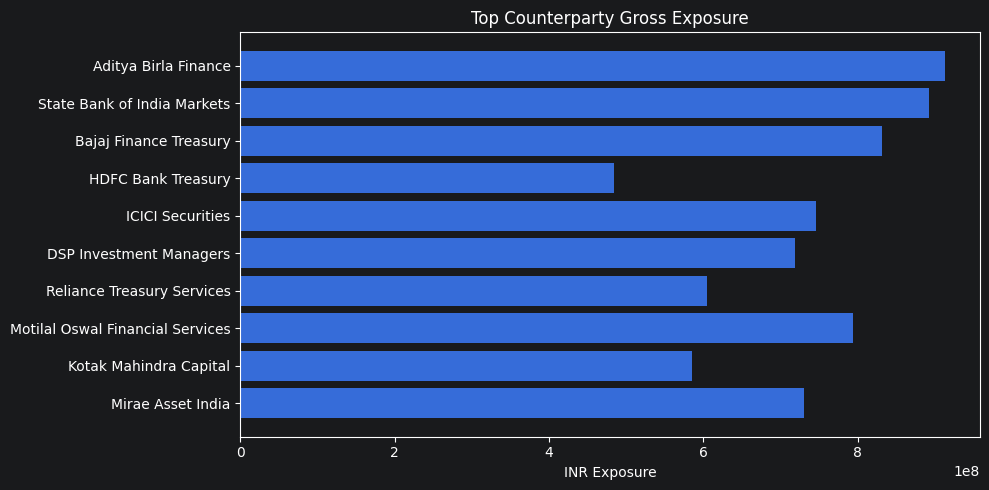

In [10]:
top_counterparties = counterparty_exposure_df.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_counterparties["counterparty_name"], top_counterparties["gross_exposure"])
plt.title("Top Counterparty Gross Exposure")
plt.xlabel("INR Exposure")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()